# 5CS037 Final Portfolio Project — Classification Task

**Dataset:** smoking_driking_dataset_Ver01.csv.

**Source:** National Health Insurance Service, Korea.

**Published:** 2024, Soo.Y

**Available at:** www.kaggle.com [Kaggle]

**UNSDG:** Goal 3 (Good Health and Well-being).

**Purpose:** Analysis of body signal and identification of drinker.

**Features:** sex, age, height, weight, sight_left, sight_right, hear_left, hear_right, SBP, DBP, BLDS, tot_chole, HDL_chole, LDL_chole, triglyceride, hemoglobin, urine_protein, serum_creatinine, SGOT_AST, SGOT_ALT, gamma_GTP, SMK_stat_type_cd, DRK_YN.

**Features Count**: 22.

**Target Feature:** DRK_YN (drinking status: Yes/No).

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

from scipy import sparse

In [ ]:
# FIX pd.read_csv
import pandas as pd
import importlib
importlib.reload(pd)

<module 'pandas' from '/usr/local/lib/python3.12/dist-packages/pandas/__init__.py'>

In [37]:
# Load Dataset
raw_data = pd.read_csv('/content/drive/MyDrive/BINOD1/smoking_driking_dataset_Ver01.csv')

print("Dataset Shape:", raw_data.shape)
print("\nColumns:", raw_data.columns.tolist())
print("\nData Types:\n", raw_data.dtypes)

# Basic exploration
display(raw_data.head(10))
display(raw_data.info())
display(raw_data.describe())

# Target variable distribution
print("\nDRK_YN Distribution:")
display(raw_data['DRK_YN'].value_counts(dropna=False))
display((raw_data['DRK_YN'].value_counts(normalize=True) * 100).round(2))

Dataset Shape: (991346, 24)

Columns: ['sex', 'age', 'height', 'weight', 'waistline', 'sight_left', 'sight_right', 'hear_left', 'hear_right', 'SBP', 'DBP', 'BLDS', 'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin', 'urine_protein', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT', 'gamma_GTP', 'SMK_stat_type_cd', 'DRK_YN']

Data Types:
 sex                  object
age                   int64
height                int64
weight                int64
waistline           float64
sight_left          float64
sight_right         float64
hear_left           float64
hear_right          float64
SBP                 float64
DBP                 float64
BLDS                float64
tot_chole           float64
HDL_chole           float64
LDL_chole           float64
triglyceride        float64
hemoglobin          float64
urine_protein       float64
serum_creatinine    float64
SGOT_AST            float64
SGOT_ALT            float64
gamma_GTP           float64
SMK_stat_type_cd    float64
DRK_Y

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N
5,Male,50,165,55,75.0,1.2,1.5,1.0,1.0,142.0,...,95.0,232.0,13.8,3.0,0.8,29.0,40.0,37.0,3.0,Y
6,Female,45,150,55,69.0,0.5,0.4,1.0,1.0,101.0,...,115.0,75.0,12.3,1.0,0.8,19.0,12.0,12.0,1.0,N
7,Male,35,175,65,84.2,1.2,1.0,1.0,1.0,132.0,...,107.0,101.0,14.4,1.0,0.8,18.0,18.0,35.0,3.0,Y
8,Male,55,170,75,84.0,1.2,0.9,1.0,1.0,145.0,...,141.0,100.0,15.1,1.0,0.8,32.0,23.0,26.0,1.0,Y
9,Male,40,175,75,82.0,1.5,1.5,1.0,1.0,132.0,...,118.0,83.0,13.9,1.0,0.9,21.0,38.0,16.0,2.0,Y


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991346 entries, 0 to 991345
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   sex               991346 non-null  object 
 1   age               991346 non-null  int64  
 2   height            991346 non-null  int64  
 3   weight            991346 non-null  int64  
 4   waistline         991346 non-null  float64
 5   sight_left        991346 non-null  float64
 6   sight_right       991346 non-null  float64
 7   hear_left         991346 non-null  float64
 8   hear_right        991346 non-null  float64
 9   SBP               991346 non-null  float64
 10  DBP               991346 non-null  float64
 11  BLDS              991346 non-null  float64
 12  tot_chole         991346 non-null  float64
 13  HDL_chole         991346 non-null  float64
 14  LDL_chole         991346 non-null  float64
 15  triglyceride      991346 non-null  float64
 16  hemoglobin        99

None

,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,DBP,...,HDL_chole,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd
count,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,...,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000
mean,47.614491,162.240625,63.284050,81.233358,0.980834,0.978429,1.031495,1.030476,122.432498,76.052627,...,56.936800,113.037692,132.141751,14.229824,1.094224,0.860467,25.989308,25.755051,37.136347,1.608122
std,14.181339,9.282957,12.514241,11.850323,0.605949,0.604774,0.174650,0.171892,14.543148,9.889365,...,17.238479,35.842812,102.196985,1.584929,0.437724,0.480530,23.493386,26.308599,50.424153,0.818507
min,20.000000,130.000000,25.000000,8.000000,0.100000,0.100000,1.000000,1.000000,67.000000,32.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.100000,1.000000,1.000000,1.000000,1.000000
25%,35.000000,155.000000,55.000000,74.100000,0.700000,0.700000,1.000000,1.000000,112.000000,70.000000,...,46.000000,89.000000,73.000000,13.200000,1.000000,0.700000,19.000000,15.000000,16.000000,1.000000
50%,45.000000,160.000000,60.000000,81.000000,1.000000,1.000000,1.000000,1.000000,120.000000,76.000000,...,55.000000,111.000000,106.000000,14.300000,1.000000,0.800000,23.000000,20.000000,23.000000,1.000000
75%,60.000000,170.000000,70.000000,87.800000,1.200000,1.200000,1.000000,1.000000,131.000000,82.000000,...,66.000000,135.000000,159.000000,15.400000,1.000000,1.000000,28.000000,29.000000,39.000000,2.000000
max,85.000000,190.000000,140.000000,999.000000,9.900000,9.900000,2.000000,2.000000,273.000000,185.000000,...,8110.000000,5119.000000,9490.000000,25.000000,6.000000,98.000000,9999.000000,7210.000000,999.000000,3.000000



DRK_YN Distribution:


,count
DRK_YN,
N,495858
Y,495488


,proportion
DRK_YN,
N,50.02
Y,49.98


In [38]:
# Data Cleaning & Encoding

# Encode categorical columns
raw_data['sex'] = raw_data['sex'].map({'Male': 1, 'Female': 0})
raw_data['DRK_YN'] = raw_data['DRK_YN'].map({'Y': 1, 'N': 0})

# Convert smoking status to integer
raw_data['SMK_stat_type_cd'] = raw_data['SMK_stat_type_cd'].astype(int)

# Remove duplicate rows
print("Initial duplicate count:", raw_data.duplicated().sum())
raw_data = raw_data.drop_duplicates()
print("Duplicates after removal:", raw_data.duplicated().sum())

# Handle missing values
print("\nMissing values per column:\n", raw_data.isna().sum())
raw_data = raw_data.dropna()

# Sample dataset if too large
if len(raw_data) > 50000:
    data = raw_data.sample(n=50000, random_state=42).reset_index(drop=True)
else:
    data = raw_data.copy()

print("\nFinal dataset shape:", data.shape)
display(data.head())

Initial duplicate count: 26
Duplicates after removal: 0

Missing values per column:
 sex                 0
age                 0
height              0
weight              0
waistline           0
sight_left          0
sight_right         0
hear_left           0
hear_right          0
SBP                 0
DBP                 0
BLDS                0
tot_chole           0
HDL_chole           0
LDL_chole           0
triglyceride        0
hemoglobin          0
urine_protein       0
serum_creatinine    0
SGOT_AST            0
SGOT_ALT            0
gamma_GTP           0
SMK_stat_type_cd    0
DRK_YN              0
dtype: int64

Final dataset shape: (50000, 24)


,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,1,45,165,70,91.0,0.9,1.5,1.0,1.0,138.0,...,69.0,142.0,15.8,1.0,0.8,28.0,20.0,60.0,3,1
1,1,75,165,60,85.0,0.6,0.7,1.0,1.0,165.0,...,43.0,205.0,14.9,1.0,0.8,13.0,16.0,23.0,1,0
2,1,35,165,65,76.0,1.2,1.2,1.0,1.0,134.0,...,138.0,107.0,16.6,1.0,0.9,17.0,19.0,33.0,3,1
3,0,60,145,50,80.0,0.6,0.9,1.0,1.0,116.0,...,69.0,251.0,12.2,5.0,1.3,21.0,12.0,13.0,1,0
4,0,55,155,45,60.0,1.5,1.0,1.0,1.0,100.0,...,110.0,101.0,13.2,1.0,0.9,16.0,12.0,14.0,1,0


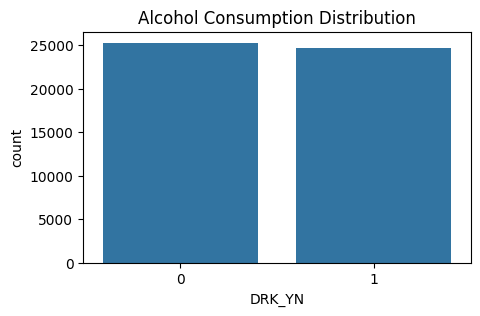

Numerical Columns: ['sex', 'age', 'height', 'weight', 'waistline', 'sight_left', 'sight_right', 'hear_left', 'hear_right', 'SBP', 'DBP', 'BLDS', 'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin', 'urine_protein', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT', 'gamma_GTP']


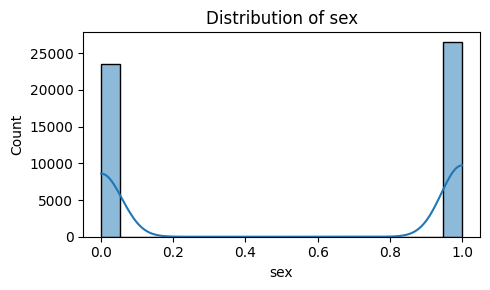

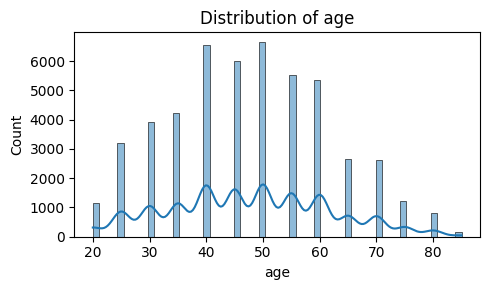

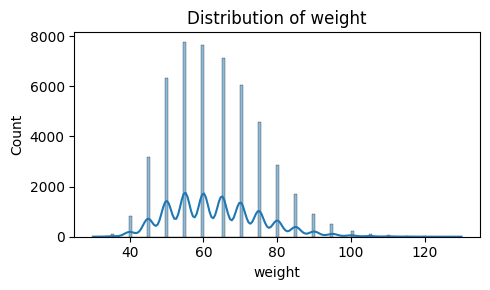

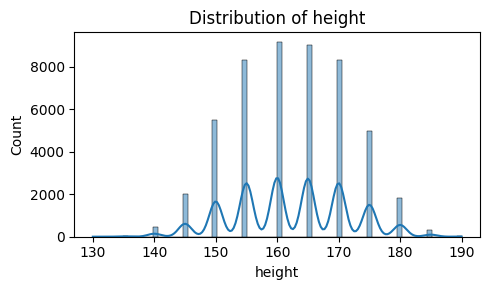

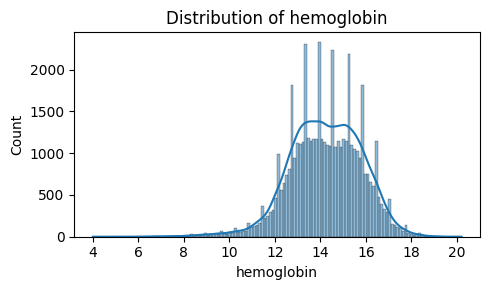

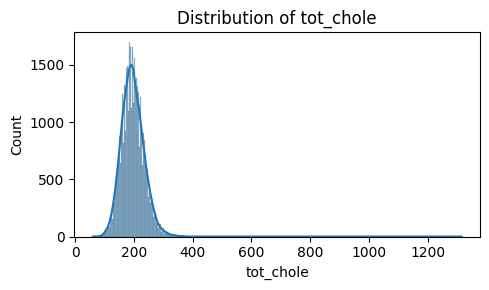

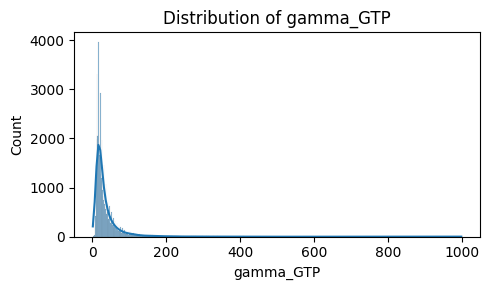

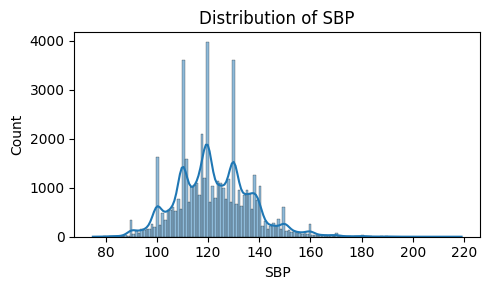

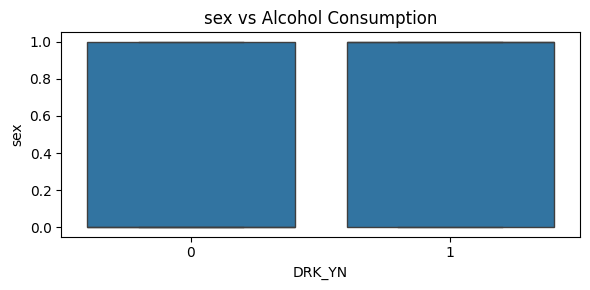

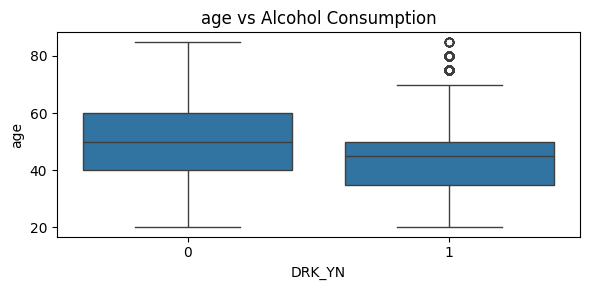

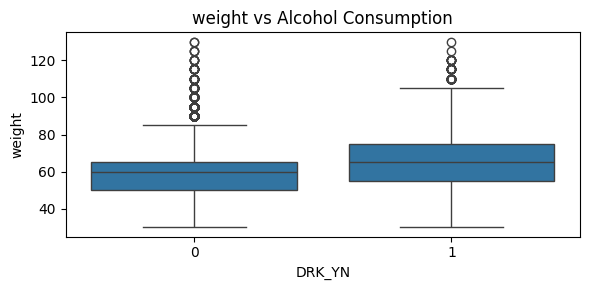

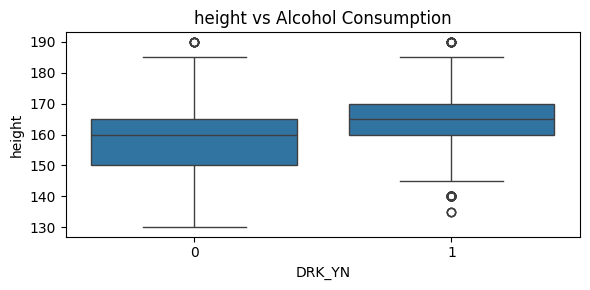

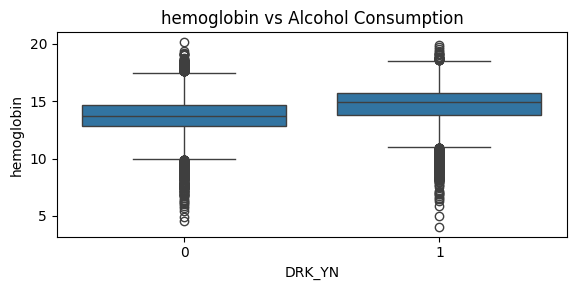

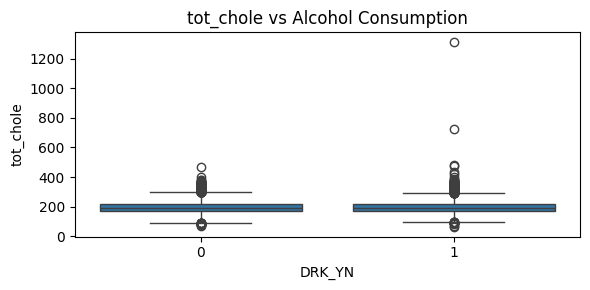

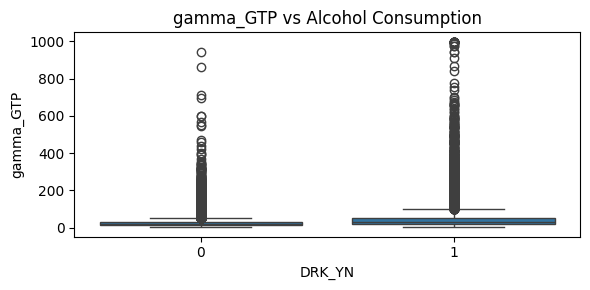

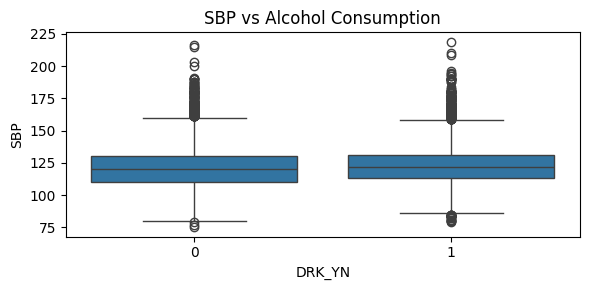

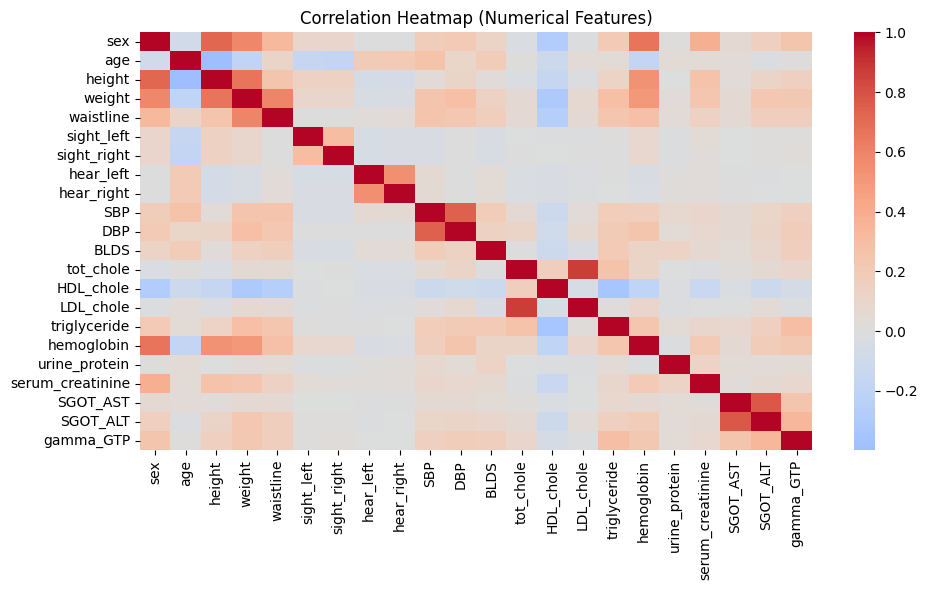

In [39]:
# Exploratory Data Analysis

# Target distribution by sex
plt.figure(figsize=(5, 3))
sns.countplot(x='DRK_YN', data=data)
plt.title("Alcohol Consumption Distribution")
plt.show()

# Prepare features and target
X = data.drop(columns=['DRK_YN', 'SMK_stat_type_cd'])
y = data['DRK_YN']

num_cols = X.select_dtypes(include=np.number).columns.tolist()
print("Numerical Columns:", num_cols)

# Selected columns for visualization
vis_cols = ['sex', 'age', 'weight', 'height', 'hemoglobin', 'tot_chole', 'gamma_GTP', 'SBP']

# Distribution plots
for col in vis_cols:
    plt.figure(figsize=(5, 3))
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

# Box plots vs Target
for col in vis_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=data["DRK_YN"], y=data[col])
    plt.title(f"{col} vs Alcohol Consumption")
    plt.tight_layout()
    plt.show()

# Correlation Heatmap
if len(num_cols) > 1:
    corr_matrix = data[num_cols].corr()
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
    plt.title("Correlation Heatmap (Numerical Features)")
    plt.tight_layout()
    plt.show()

In [40]:
# Train-Test Split (70/30)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (35000, 22)
Test set shape: (15000, 22)


In [41]:
# Preprocessing Pipeline

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:", len(num_cols))
print("Categorical features:", cat_cols)

# Preprocessors
num_imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

cat_imputer = SimpleImputer(strategy="most_frequent")
onehot = OneHotEncoder(handle_unknown="ignore")

# Process numerical features
X_train_num = num_imputer.fit_transform(X_train[num_cols]) if num_cols else np.empty((len(X_train), 0))
X_test_num = num_imputer.transform(X_test[num_cols]) if num_cols else np.empty((len(X_test), 0))

X_train_num = scaler.fit_transform(X_train_num) if X_train_num.shape[1] > 0 else X_train_num
X_test_num = scaler.transform(X_test_num) if X_test_num.shape[1] > 0 else X_test_num

# Process categorical features
if cat_cols:
    X_train_cat_raw = cat_imputer.fit_transform(X_train[cat_cols])
    X_test_cat_raw = cat_imputer.transform(X_test[cat_cols])

    X_train_cat = onehot.fit_transform(X_train_cat_raw)
    X_test_cat = onehot.transform(X_test_cat_raw)
else:
    X_train_cat = sparse.csr_matrix((len(X_train), 0))
    X_test_cat = sparse.csr_matrix((len(X_test), 0))

# Combine numerical and categorical features
X_train_final = sparse.hstack([sparse.csr_matrix(X_train_num), X_train_cat]).tocsr()
X_test_final = sparse.hstack([sparse.csr_matrix(X_test_num), X_test_cat]).tocsr()

print("Final train shape:", X_train_final.shape)
print("Final test shape:", X_test_final.shape)

Numerical features: 22
Categorical features: []
Final train shape: (35000, 22)
Final test shape: (15000, 22)


In [42]:
# Model Evaluation Function
def evaluate_classifier(model_name, model, X_train, y_train, X_test, y_test):
    """
    Train model and evaluate performance using multiple metrics.
    """
    # Train the model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Display results
    print(f"\n=== {model_name} ===")
    print(f"Accuracy  : {round(acc, 4)}")
    print(f"Precision : {round(prec, 4)}")
    print(f"Recall    : {round(rec, 4)}")
    print(f"F1 Score  : {round(f1, 4)}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    }


=== Neural Network (MLP) ===
Accuracy  : 0.7355
Precision : 0.7316
Recall    : 0.7338
F1 Score  : 0.7327

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      7589
           1       0.73      0.73      0.73      7411

    accuracy                           0.74     15000
   macro avg       0.74      0.74      0.74     15000
weighted avg       0.74      0.74      0.74     15000



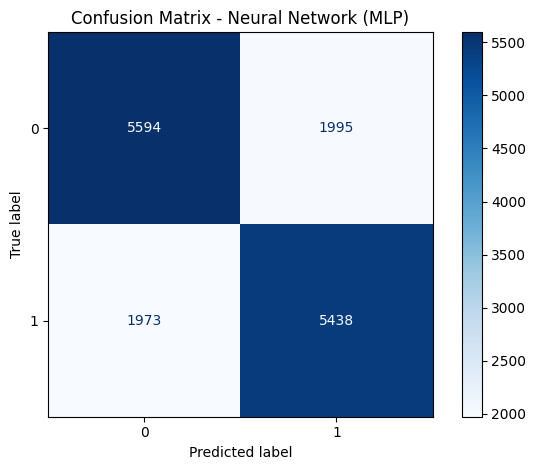

,Model,Accuracy,Precision,Recall,F1
0,Neural Network (MLP),0.735467,0.731602,0.733774,0.732687


In [43]:
# Neural Network - MLPClassifier
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    random_state=42
)

mlp_result = evaluate_classifier("Neural Network (MLP)", mlp_model,
                                 X_train_final, y_train,
                                 X_test_final, y_test)

pd.DataFrame([mlp_result])


=== Logistic Regression (Baseline) ===
Accuracy  : 0.7281
Precision : 0.7308
Recall    : 0.712
F1 Score  : 0.7213

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.74      0.73      7589
           1       0.73      0.71      0.72      7411

    accuracy                           0.73     15000
   macro avg       0.73      0.73      0.73     15000
weighted avg       0.73      0.73      0.73     15000



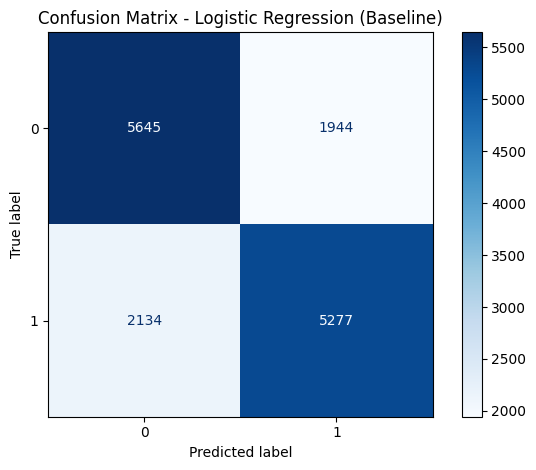


=== Random Forest (Baseline) ===
Accuracy  : 0.7279
Precision : 0.7255
Recall    : 0.7227
F1 Score  : 0.7241

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.73      0.73      7589
           1       0.73      0.72      0.72      7411

    accuracy                           0.73     15000
   macro avg       0.73      0.73      0.73     15000
weighted avg       0.73      0.73      0.73     15000



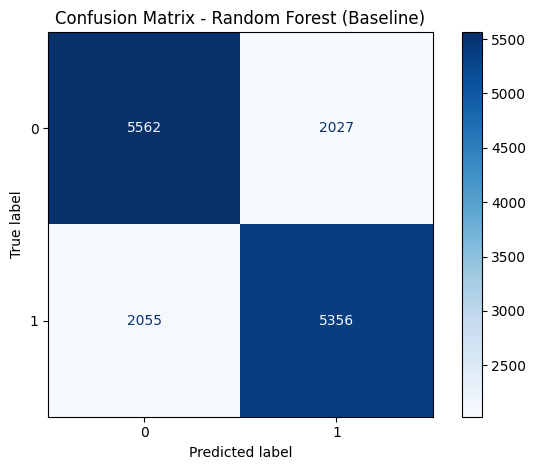

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression (Baseline),0.728133,0.730785,0.712050,0.721296
1,Random Forest (Baseline),0.727867,0.725450,0.722709,0.724077


In [44]:
# Baseline Models

# 1. Logistic Regression
log_reg = LogisticRegression(
    max_iter=3000,
    solver="saga",
    n_jobs=-1,
    random_state=42
)

# 2. Random Forest
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=300,
    n_jobs=-1
)

# Evaluate both models
results = []

results.append(evaluate_classifier("Logistic Regression (Baseline)",
                                  log_reg, X_train_final, y_train, X_test_final, y_test))

results.append(evaluate_classifier("Random Forest (Baseline)",
                                  rf_model, X_train_final, y_train, X_test_final, y_test))

# Show summary
pd.DataFrame(results)

In [46]:
# Fast Hyperparameter Tuning (Recommended)

TUNE_SIZE = 30_000   # Smaller sample for speed

if X_train_final.shape[0] > TUNE_SIZE:
    idx = np.arange(X_train_final.shape[0])
    idx_small, _, y_small, _ = train_test_split(
        idx, y_train, train_size=TUNE_SIZE, stratify=y_train, random_state=42
    )
    X_tune = X_train_final[idx_small]
    y_tune = y_train.iloc[idx_small]
else:
    X_tune = X_train_final
    y_tune = y_train

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # Reduced folds



# 1. Logistic Regression (Fast)
logreg_search = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=2000, solver="saga", n_jobs=-1, random_state=42),
    param_distributions={"C": [0.1, 1, 10]},
    n_iter=3,
    scoring="accuracy",
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
logreg_search.fit(X_tune, y_tune)
print("Best LogReg params:", logreg_search.best_params_)
print("Best LogReg CV Score:", round(logreg_search.best_score_, 4))

# 2. Random Forest (Fast)
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions={
        "n_estimators": [200, 300],
        "max_depth": [None, 20],
        "min_samples_split": [2, 5],
        "max_features": ["sqrt"]
    },
    n_iter=6,
    scoring="accuracy",
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_search.fit(X_tune, y_tune)
print("Best RF params:", rf_search.best_params_)
print("Best RF CV Score:", round(rf_search.best_score_, 4))

Starting Fast Tuning...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best LogReg params: {'C': 0.1}
Best LogReg CV Score: 0.7224
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best RF params: {'n_estimators': 300, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': 20}
Best RF CV Score: 0.7268



=== Logistic Regression (Tuned) ===
Accuracy  : 0.7277
Precision : 0.7303
Recall    : 0.7116
F1 Score  : 0.7208

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.74      0.73      7589
           1       0.73      0.71      0.72      7411

    accuracy                           0.73     15000
   macro avg       0.73      0.73      0.73     15000
weighted avg       0.73      0.73      0.73     15000



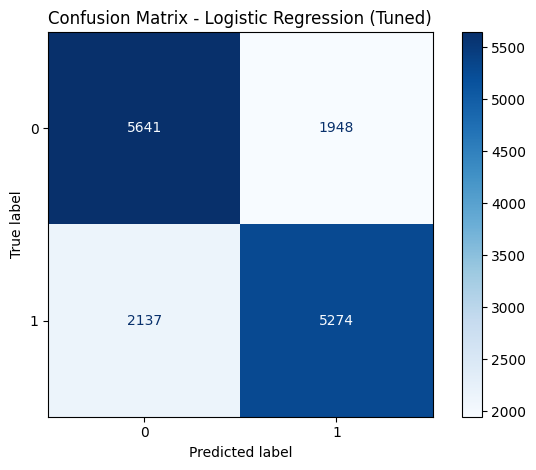


=== Random Forest (Tuned) ===
Accuracy  : 0.7297
Precision : 0.7257
Recall    : 0.7282
F1 Score  : 0.727

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.73      0.73      7589
           1       0.73      0.73      0.73      7411

    accuracy                           0.73     15000
   macro avg       0.73      0.73      0.73     15000
weighted avg       0.73      0.73      0.73     15000



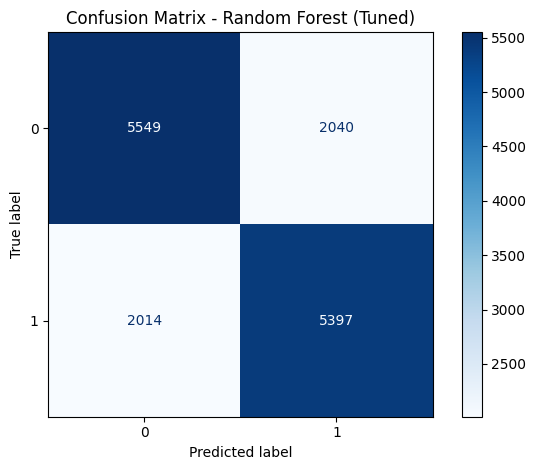

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression (Tuned),0.727667,0.730269,0.711645,0.720836
1,Random Forest (Tuned),0.729733,0.725696,0.728242,0.726967


In [48]:
# Evaluate Tuned Models on Full Test Set

best_logreg = logreg_search.best_estimator_
best_rf = rf_search.best_estimator_

tuned_results = []

tuned_results.append(evaluate_classifier("Logistic Regression (Tuned)",
                                        best_logreg,
                                        X_train_final, y_train,
                                        X_test_final, y_test))

tuned_results.append(evaluate_classifier("Random Forest (Tuned)",
                                        best_rf,
                                        X_train_final, y_train,
                                        X_test_final, y_test))

# Summary Table
pd.DataFrame(tuned_results)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.1


=== LogReg + FS (K=5) ===
Accuracy  : 0.7113
Precision : 0.7159
Recall    : 0.689
F1 Score  : 0.7022

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.73      0.72      7589
           1       0.72      0.69      0.70      7411

    accuracy                           0.71     15000
   macro avg       0.71      0.71      0.71     15000
weighted avg       0.71      0.71      0.71     15000



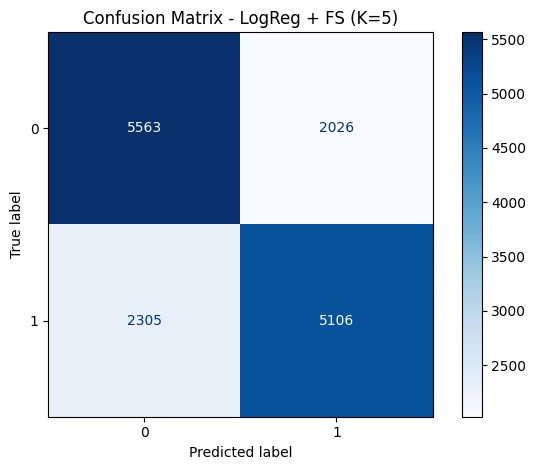


=== RF + FS (K=5) ===
Accuracy  : 0.6947
Precision : 0.6856
Recall    : 0.7057
F1 Score  : 0.6955

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.68      0.69      7589
           1       0.69      0.71      0.70      7411

    accuracy                           0.69     15000
   macro avg       0.69      0.69      0.69     15000
weighted avg       0.70      0.69      0.69     15000



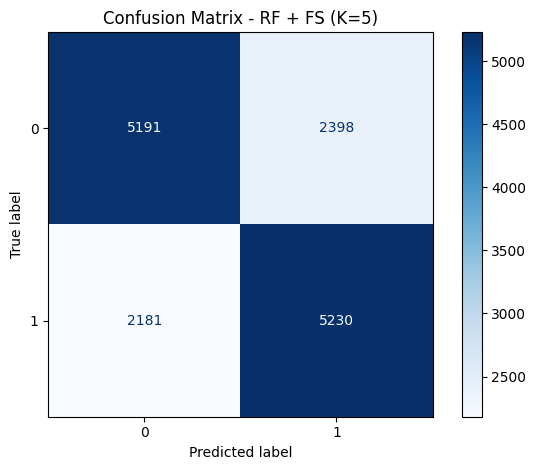

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.1


=== LogReg + FS (K=10) ===
Accuracy  : 0.7121
Precision : 0.7156
Recall    : 0.6923
F1 Score  : 0.7038

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.73      0.72      7589
           1       0.72      0.69      0.70      7411

    accuracy                           0.71     15000
   macro avg       0.71      0.71      0.71     15000
weighted avg       0.71      0.71      0.71     15000



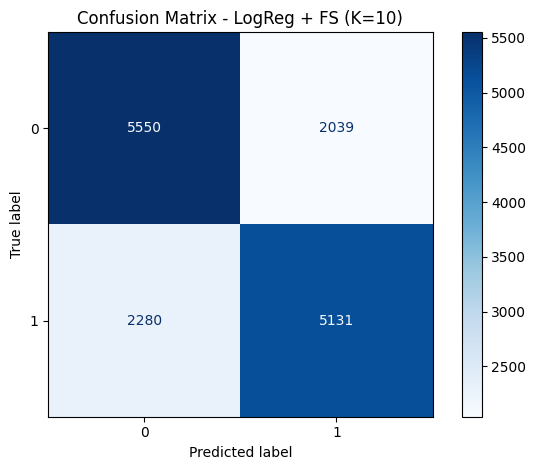


=== RF + FS (K=10) ===
Accuracy  : 0.7157
Precision : 0.7078
Recall    : 0.7231
F1 Score  : 0.7154

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.71      0.72      7589
           1       0.71      0.72      0.72      7411

    accuracy                           0.72     15000
   macro avg       0.72      0.72      0.72     15000
weighted avg       0.72      0.72      0.72     15000



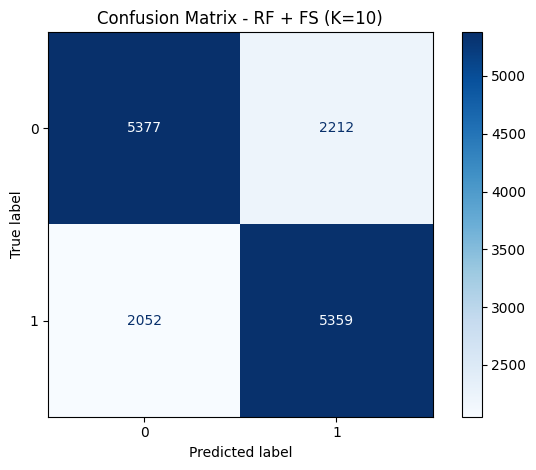

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.1


=== LogReg + FS (K=15) ===
Accuracy  : 0.7192
Precision : 0.7252
Recall    : 0.6949
F1 Score  : 0.7098

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.74      0.73      7589
           1       0.73      0.69      0.71      7411

    accuracy                           0.72     15000
   macro avg       0.72      0.72      0.72     15000
weighted avg       0.72      0.72      0.72     15000



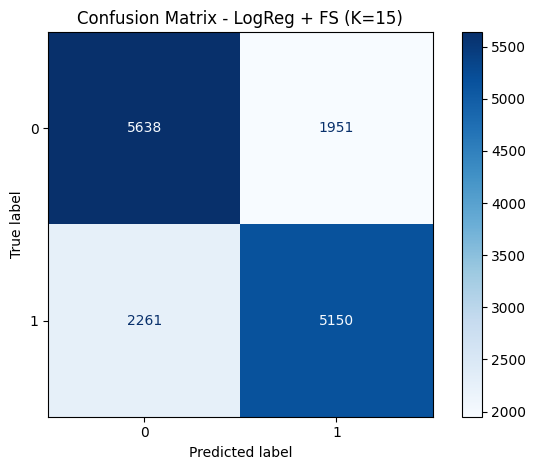


=== RF + FS (K=15) ===
Accuracy  : 0.7207
Precision : 0.7156
Recall    : 0.7212
F1 Score  : 0.7184

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.72      0.72      7589
           1       0.72      0.72      0.72      7411

    accuracy                           0.72     15000
   macro avg       0.72      0.72      0.72     15000
weighted avg       0.72      0.72      0.72     15000



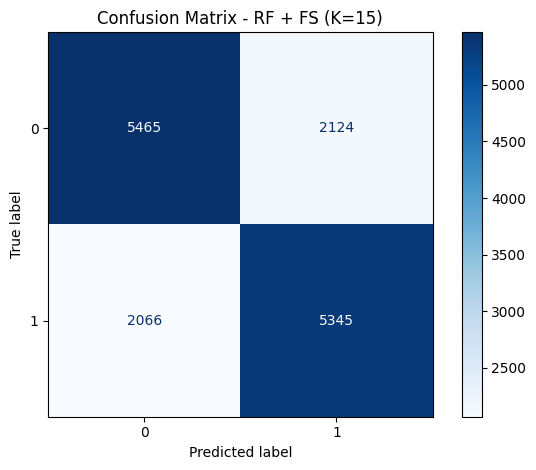

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.1


=== LogReg + FS (K=20) ===
Accuracy  : 0.7269
Precision : 0.7295
Recall    : 0.7108
F1 Score  : 0.7201

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.74      0.73      7589
           1       0.73      0.71      0.72      7411

    accuracy                           0.73     15000
   macro avg       0.73      0.73      0.73     15000
weighted avg       0.73      0.73      0.73     15000



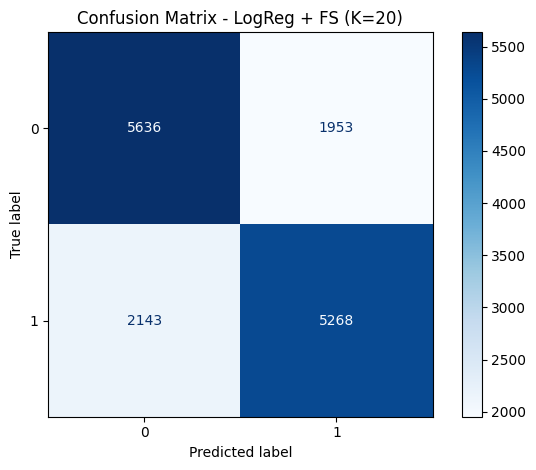


=== RF + FS (K=20) ===
Accuracy  : 0.727
Precision : 0.7242
Recall    : 0.7227
F1 Score  : 0.7234

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.73      0.73      7589
           1       0.72      0.72      0.72      7411

    accuracy                           0.73     15000
   macro avg       0.73      0.73      0.73     15000
weighted avg       0.73      0.73      0.73     15000



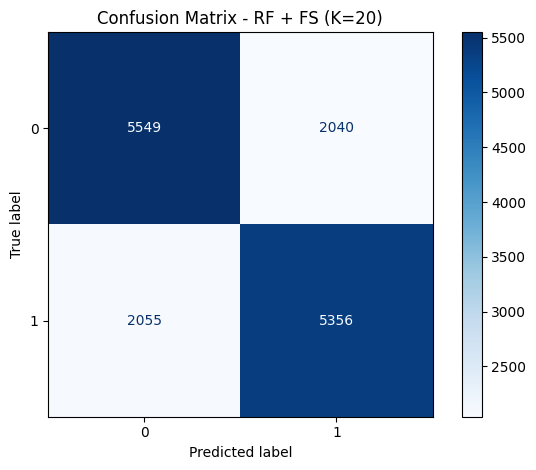

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.1


=== LogReg + FS (K=all) ===
Accuracy  : 0.7277
Precision : 0.7303
Recall    : 0.7116
F1 Score  : 0.7208

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.74      0.73      7589
           1       0.73      0.71      0.72      7411

    accuracy                           0.73     15000
   macro avg       0.73      0.73      0.73     15000
weighted avg       0.73      0.73      0.73     15000



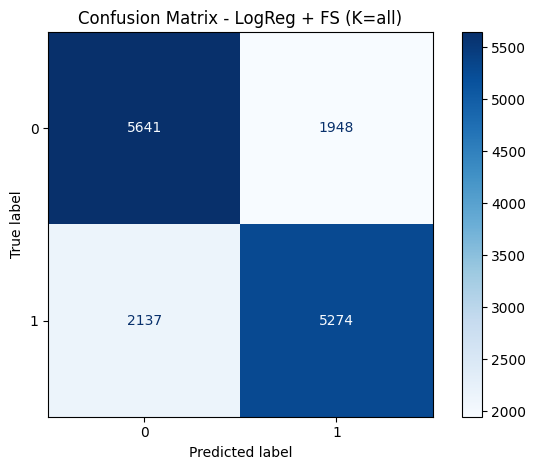


=== RF + FS (K=all) ===
Accuracy  : 0.7297
Precision : 0.7257
Recall    : 0.7282
F1 Score  : 0.727

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.73      0.73      7589
           1       0.73      0.73      0.73      7411

    accuracy                           0.73     15000
   macro avg       0.73      0.73      0.73     15000
weighted avg       0.73      0.73      0.73     15000



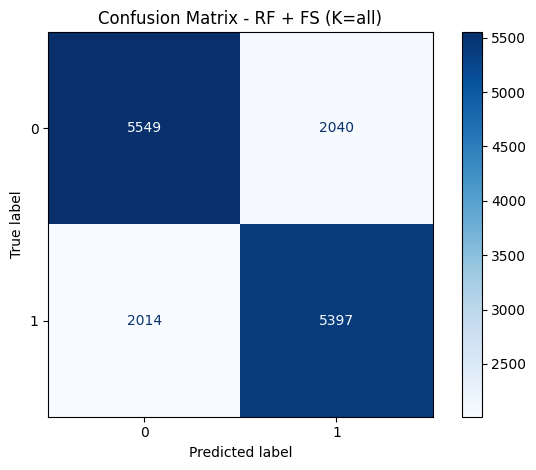

,Model,Accuracy,Precision,Recall,F1
9,RF + FS (K=all),0.729733,0.725696,0.728242,0.726967
8,LogReg + FS (K=all),0.727667,0.730269,0.711645,0.720836
7,RF + FS (K=20),0.727000,0.724175,0.722709,0.723442
6,LogReg + FS (K=20),0.726933,0.729539,0.710835,0.720066
5,RF + FS (K=15),0.720667,0.715625,0.721225,0.718414
4,LogReg + FS (K=15),0.719200,0.725250,0.694913,0.709757
3,RF + FS (K=10),0.715733,0.707833,0.723114,0.715392
2,LogReg + FS (K=10),0.712067,0.715621,0.692349,0.703793
0,LogReg + FS (K=5),0.711267,0.715928,0.688976,0.702193
1,RF + FS (K=5),0.694733,0.685632,0.705708,0.695525


In [50]:
# Feature Selection using SelectKBest

k_options = [5, 10, 15, 20, "all"]
fs_results = []

for k in k_options:
    # Apply feature selection
    selector = SelectKBest(mutual_info_classif, k=k)
    X_train_fs = selector.fit_transform(X_train_final, y_train)
    X_test_fs = selector.transform(X_test_final)

    # Use best parameters from tuning
    lr_fs = LogisticRegression(
        max_iter=3000,
        solver="saga",
        n_jobs=-1,
        random_state=42,
        C=best_logreg.C
    )

    rf_fs = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        **rf_search.best_params_
    )

    # Evaluate
    fs_results.append(evaluate_classifier(f"LogReg + FS (K={k})",
                                         lr_fs, X_train_fs, y_train, X_test_fs, y_test))

    fs_results.append(evaluate_classifier(f"RF + FS (K={k})",
                                         rf_fs, X_train_fs, y_train, X_test_fs, y_test))

# Show best results
pd.DataFrame(fs_results).sort_values("Accuracy", ascending=False).head(10)

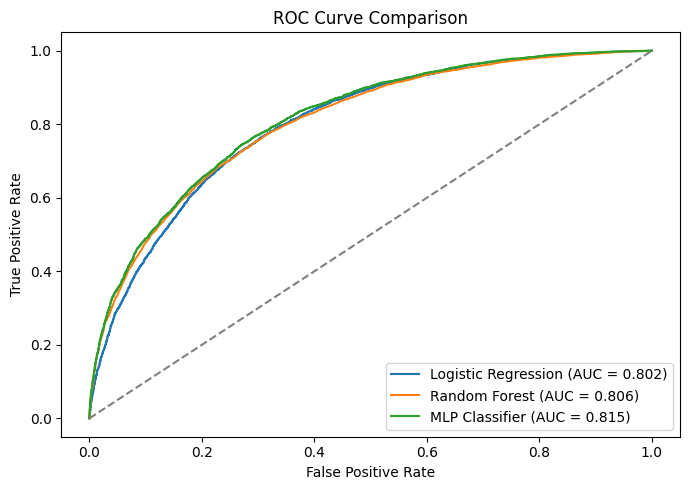

In [51]:
# ROC Curve Comparison

models_dict = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_model,
    "MLP Classifier": mlp_model
}

plt.figure(figsize=(7, 5))

for name, model in models_dict.items():
    model.fit(X_train_final, y_train)
    y_prob = model.predict_proba(X_test_final)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()